# Integrated Clustering Report Builder

이 노트북은 통합 군집화 리포트 산출물을 한 번에 확인하기 위한 메인 노트북이다.

확인 가능한 항목:
- 반납 시간대 기반 지구판단 피처 생성 결과
- 통합 군집화 입력과 군집 결과
- 환경 보강 피처와 보강 실험 결과
- 발표 문서에 들어가는 차트와 지도 산출물

권장 사용 순서:
1. 위에서 아래로 순서대로 실행
2. `final/`과 `intermediate/` 산출물이 어디에 저장되는지 함께 확인
3. 최종 결과는 `final/results/second_clustering_results/`에서 확인


# Ddri 통합 군집화 발표 레포트 생성 노트북

이 노트북은 강남구 따릉이 통합 군집화 발표 레포트를 만들기 위한 단일 실행 진입점입니다.

구성:
- 반납 시간대 기반 지구판단 피처 생성
- 기본 통합 군집화 실행 및 차트 생성
- 환경 보강 피처 생성
- 환경 보강 군집화 실행 및 비교
- 발표용 핵심 표와 차트 요약

원천 데이터는 기존 공유폴더/works 산출물을 사용하며, 이 노트북은 `works/01_clustering/08_integrated/` 아래 결과를 재생성합니다.

In [1]:
from __future__ import annotations

from pathlib import Path
import runpy

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

ROOT = Path('/Users/works/01_clustering/08_integrated/Desktop/ddri_work')
CHENG80 = ROOT / 'cheng80'

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

display(Markdown('## 경로 확인'))
print('ROOT =', ROOT)
print('CHENG80 =', CHENG80)

## 경로 확인

ROOT = /Users/works/01_clustering/08_integrated/Desktop/ddri_work
INTEGRATED = /Users/works/01_clustering/08_integrated/Desktop/ddri_work/works/01_clustering/08_integrated


## 1. 실행할 파이프라인

검증이 끝난 기존 스크립트를 이 노트북에서 순차 실행합니다.

이 접근의 장점:
- 산출 로직을 다시 복붙하지 않아도 됨
- 한 번의 실행으로 데이터 가공, 군집화, 차트 생성까지 재현 가능
- 이후 필요하면 이 노트북 안으로 함수를 더 직접 이관할 수 있음

In [2]:
PIPELINE_SCRIPTS = [
    CHENG80 / '05_build_return_time_district_features.py',
    CHENG80 / '07_run_integrated_second_clustering.py',
    CHENG80 / '08_build_environment_enrichment_features.py',
    CHENG80 / '09_analyze_environment_enrichment.py',
    CHENG80 / '10_build_enriched_clustering_inputs.py',
    CHENG80 / '11_run_enriched_second_clustering.py',
]

for script in PIPELINE_SCRIPTS:
    print(script.name)

05_build_return_time_district_features.py
07_run_integrated_second_clustering.py
08_build_environment_enrichment_features.py
09_analyze_environment_enrichment.py
10_build_enriched_clustering_inputs.py
11_run_enriched_second_clustering.py


## 2. 전체 파이프라인 실행

필요 시 이 셀 하나만 다시 실행하면 발표용 산출물을 모두 갱신할 수 있습니다.

In [3]:
for script in PIPELINE_SCRIPTS:
    print(f'\\n>>> RUN {script.name}')
    runpy.run_path(str(script), run_name='__main__')

print('\\n파이프라인 실행 완료')

\n>>> RUN 05_build_return_time_district_features.py


\n>>> RUN 07_run_integrated_second_clustering.py


\n>>> RUN 08_build_environment_enrichment_features.py


\n>>> RUN 09_analyze_environment_enrichment.py
\n>>> RUN 10_build_enriched_clustering_inputs.py
\n>>> RUN 11_run_enriched_second_clustering.py


\n파이프라인 실행 완료


## 3. 기본 통합 군집화 결과 요약

발표 메인 결과로 사용할 `기본 통합 군집화`의 탐색 결과와 군집 요약을 확인합니다.

In [4]:
base_result_dir = CHENG80 / 'second_clustering_results'
base_data_dir = base_result_dir / 'data'
base_img_dir = base_result_dir / 'images'

base_k = pd.read_csv(base_data_dir / 'ddri_second_kmeans_search_metrics.csv')
base_summary = pd.read_csv(base_data_dir / 'ddri_second_cluster_summary.csv')
base_train = pd.read_csv(base_data_dir / 'ddri_second_cluster_train_with_labels.csv')
base_rep = pd.read_csv(base_data_dir / 'ddri_second_cluster_representative_stations.csv')

display(Markdown('### k 탐색 결과'))
display(base_k)

display(Markdown('### 군집 요약'))
display(base_summary)

display(Markdown('### 대표 대여소 예시'))
display(base_rep[['cluster', 'station_id', 'station_name', 'district_hypothesis', 'center_distance']].head(15))

### k 탐색 결과

,k,inertia,silhouette
0,5,542.473316,0.203280
1,6,498.332146,0.179541
2,7,465.907711,0.170796


### 군집 요약

,cluster,arrival_7_10_ratio,arrival_11_14_ratio,arrival_17_20_ratio,morning_net_inflow,evening_net_inflow,subway_distance_m,bus_stop_count_300m,station_count
0,0,0.2832,0.1874,0.2326,1162.9388,-792.3469,472.0807,27.1837,49
1,1,0.4863,0.1599,0.1614,10421.0000,-4702.0000,435.6681,46.6667,3
2,2,0.1134,0.1497,0.3831,-2016.6562,1214.9688,390.4809,30.9688,32
3,3,0.1532,0.1975,0.3066,-489.2131,20.6066,282.7468,27.5246,61
4,4,0.1569,0.1589,0.3123,-842.8947,477.3684,1616.5686,24.8421,19


### 대표 대여소 예시

,cluster,station_id,station_name,district_hypothesis,center_distance
0,0,4908,SB타워 앞,업무/상업지구 후보,0.620905
1,0,2328,르네상스 호텔 사거리 역삼지하보도 7번출구 앞,업무/상업지구 후보,0.761847
2,0,4902,구역삼세무서 교차로,업무/상업지구 후보,0.764838
3,0,2364,도산공원교차로,업무/상업지구 후보,0.863017
4,0,4913,레베쌍트 빌딩 앞,업무/상업지구 후보,0.903989
5,1,2377,수서역 5번출구,업무/상업지구 후보,2.648127
6,1,2323,주식회사 오뚜기 정문 앞,업무/상업지구 후보,3.268810
7,1,2348,포스코사거리(기업은행),업무/상업지구 후보,3.345411
8,2,2312,청담역 13번 출구 앞,주거지구 후보,0.896887
9,2,2354,청담역 2번출구,주거지구 후보,0.989848


### 기본 통합 군집화 차트

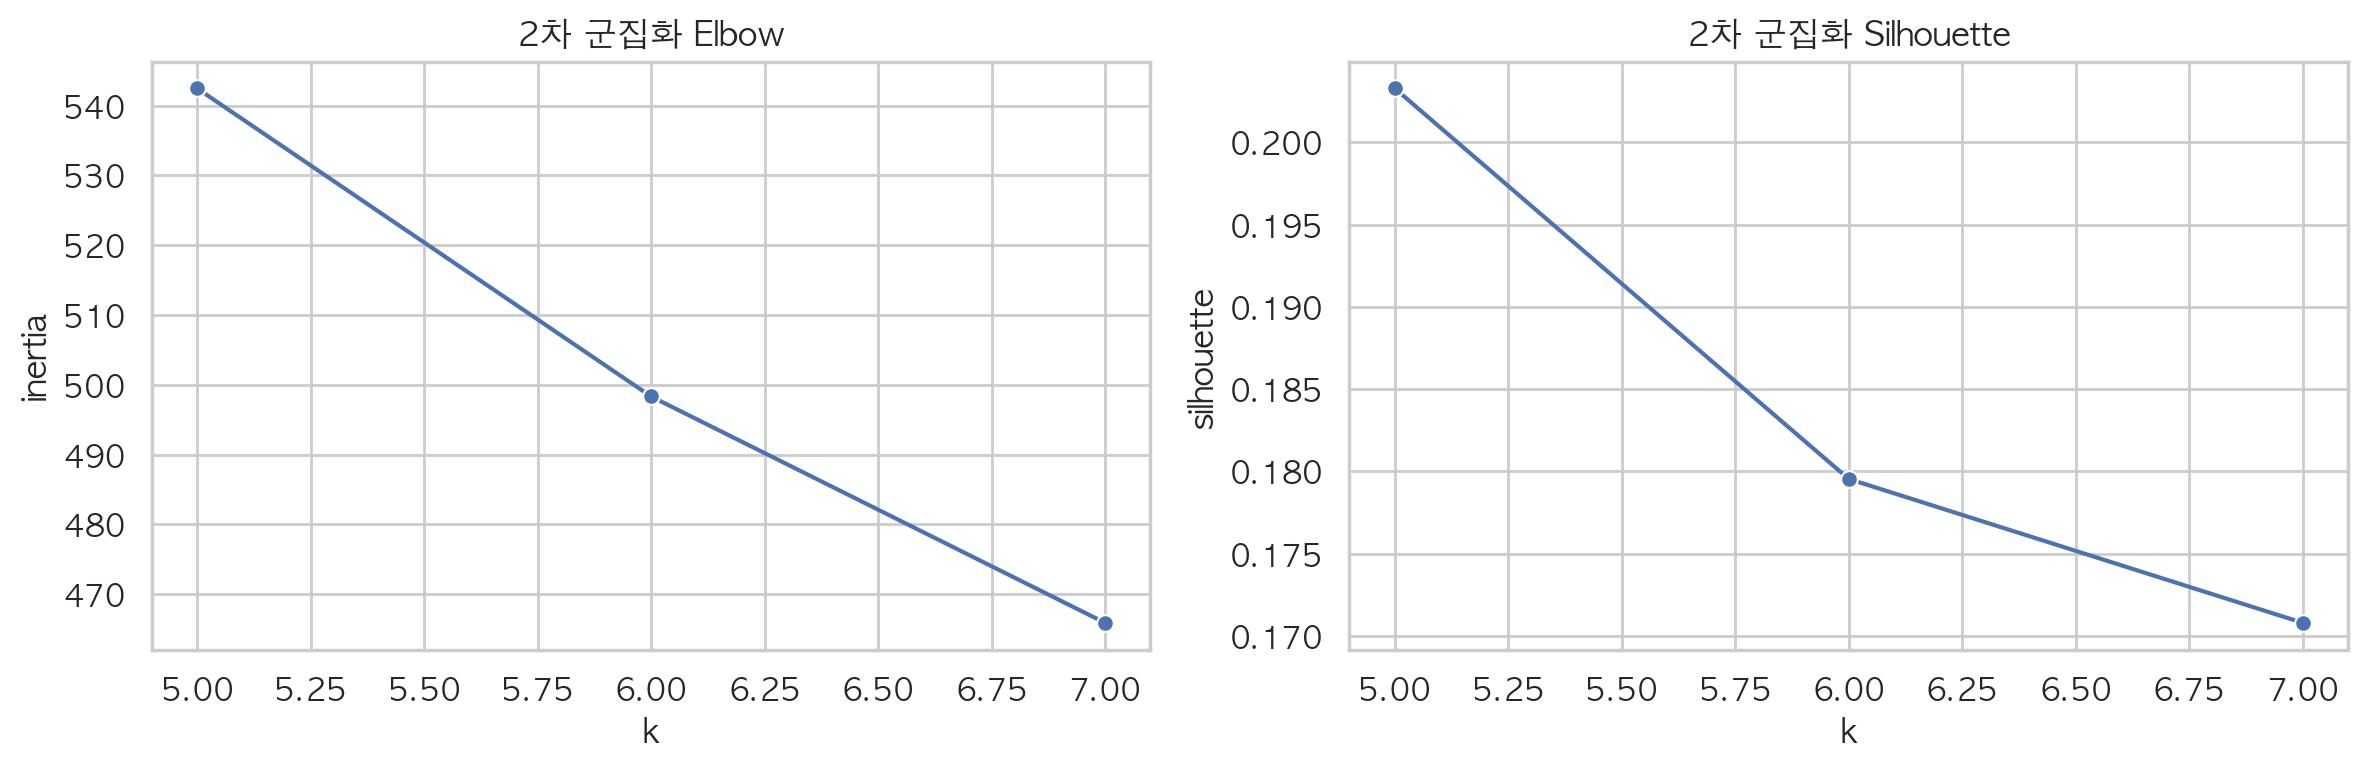

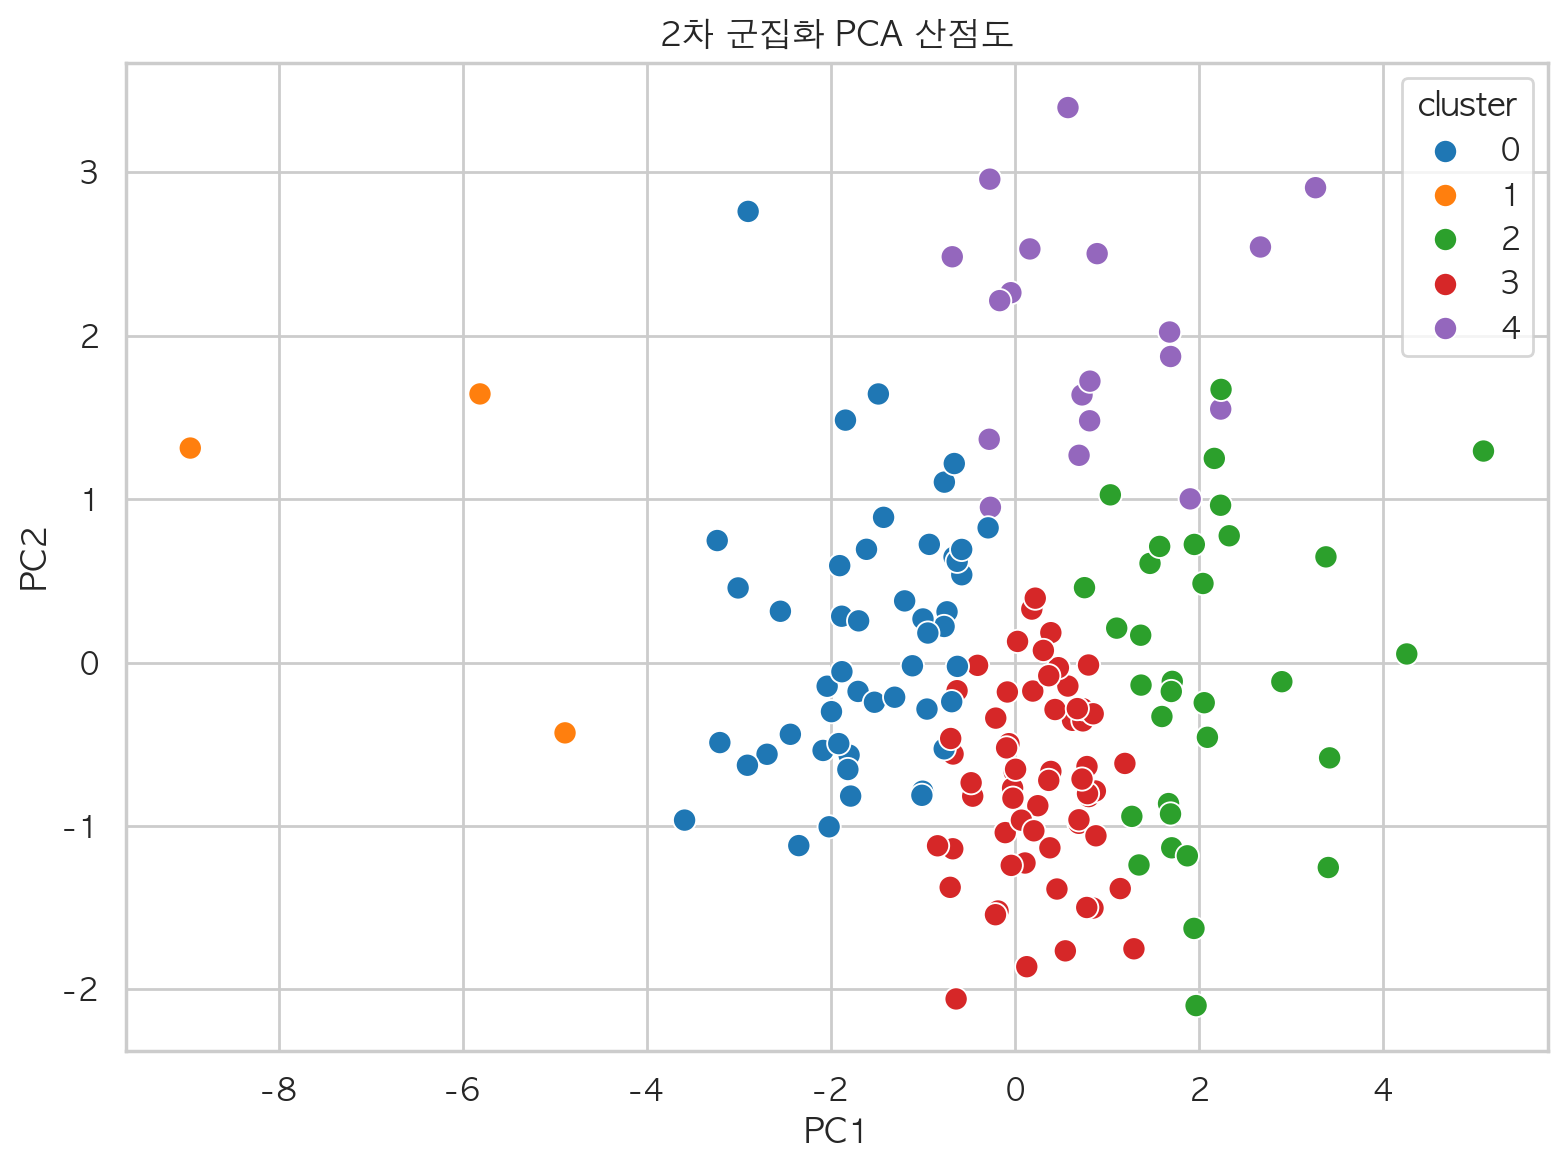

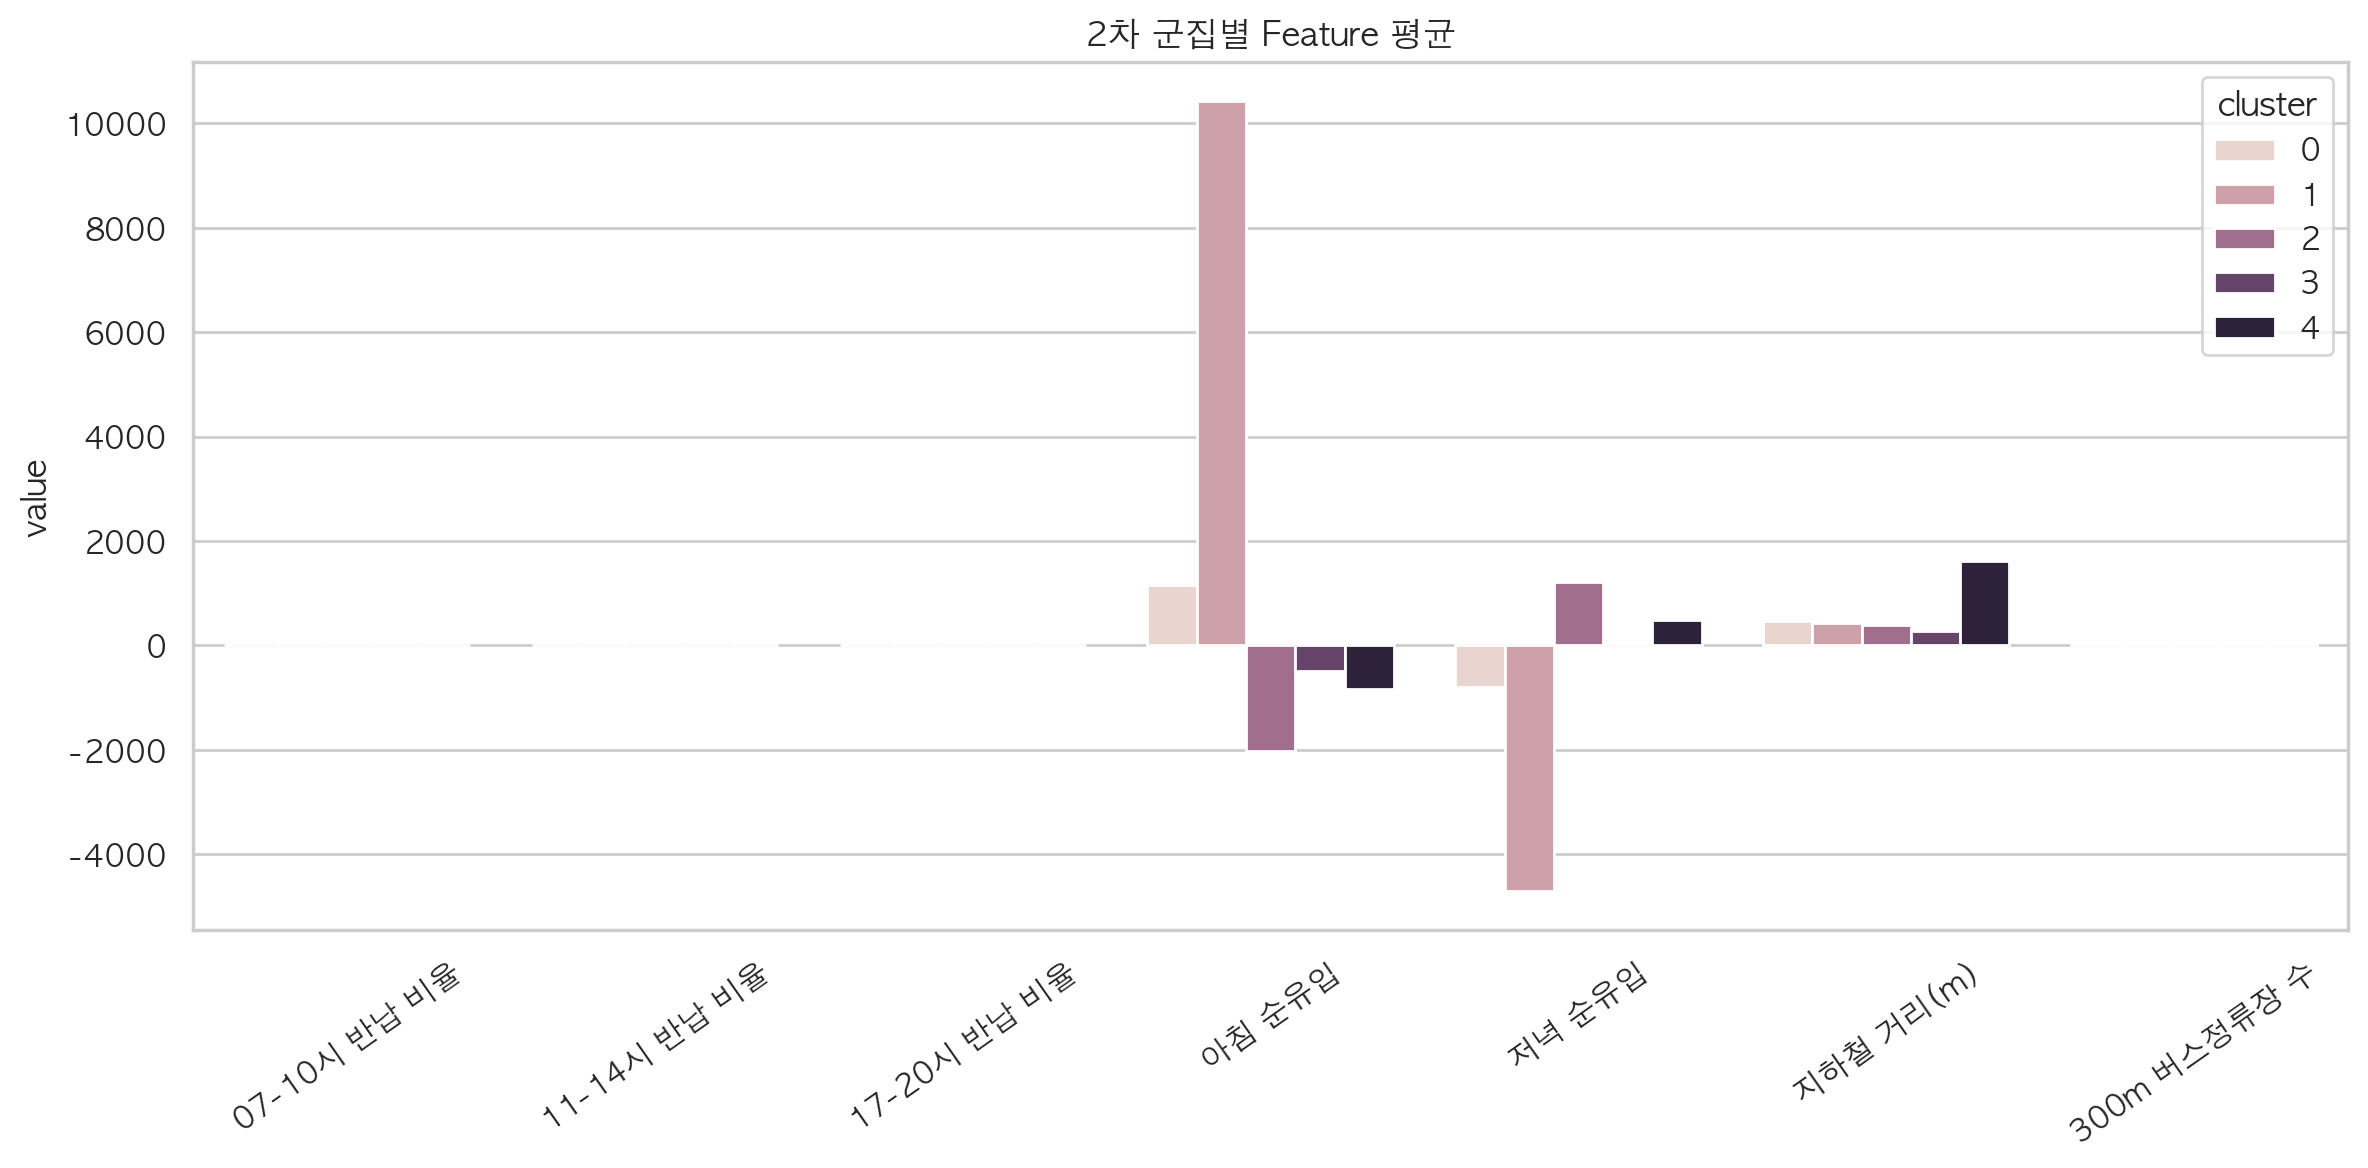

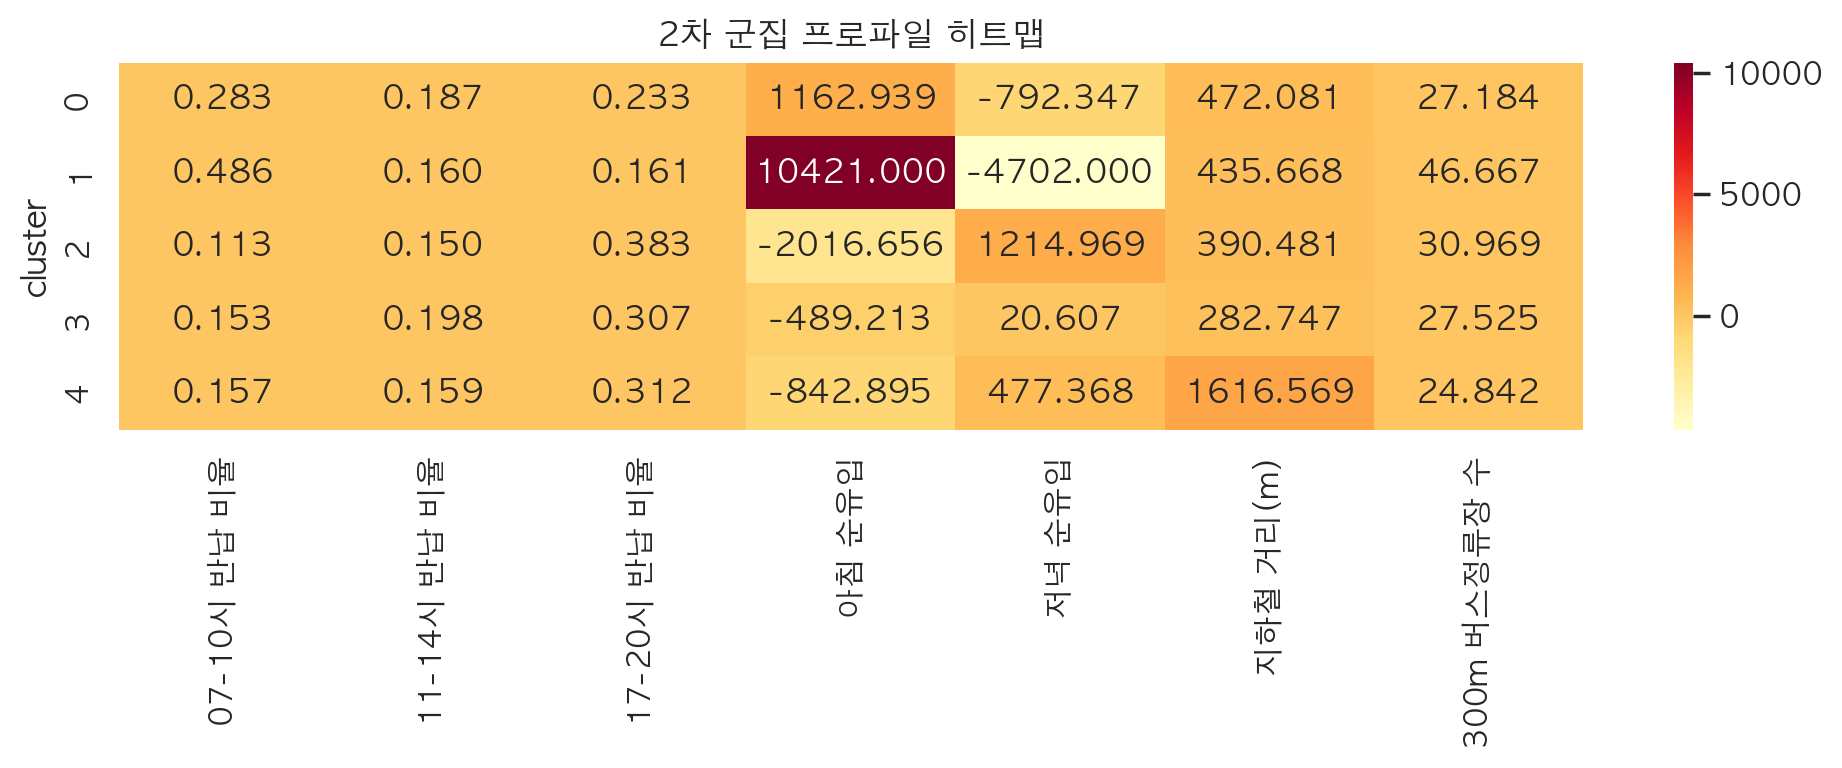

In [5]:
display(Markdown('### 기본 통합 군집화 차트'))
display(Image(filename=str(base_img_dir / 'ddri_second_kmeans_elbow_silhouette.png')))
display(Image(filename=str(base_img_dir / 'ddri_second_kmeans_pca_scatter.png')))
display(Image(filename=str(base_img_dir / 'ddri_second_cluster_feature_means.png')))
display(Image(filename=str(base_img_dir / 'ddri_second_cluster_profile_heatmap.png')))

## 3-1. 군집화 근거 보강

발표에서 군집화 근거를 충분히 제시하려면 아래 항목이 함께 필요합니다.

- 군집 수 탐색 근거
- 군집별 station 수
- 지구판단 가설 분포
- 대표 대여소 목록
- 정적 군집 지도
- 핵심 피처의 군집별 분포

### 추가 근거 차트

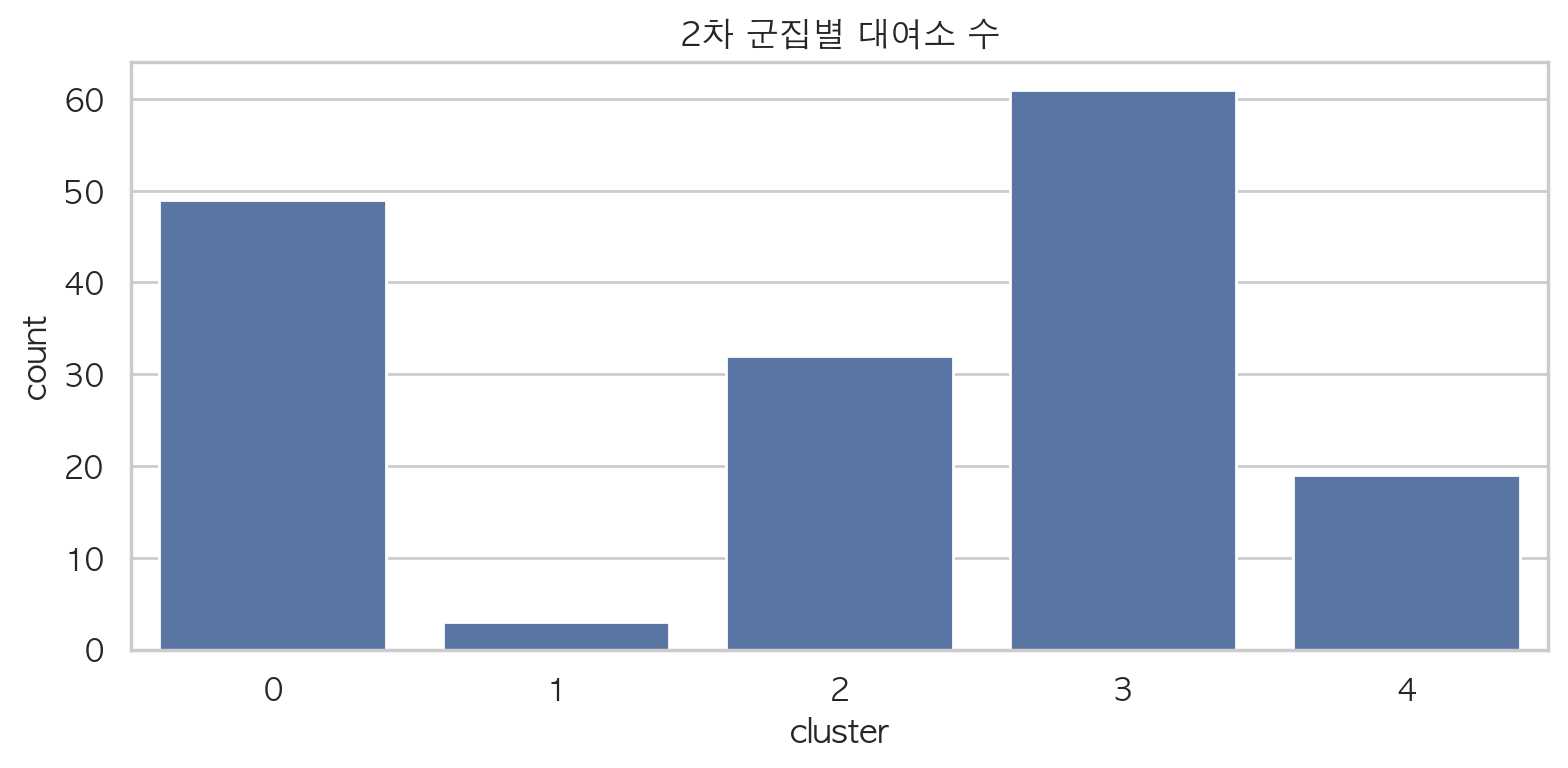

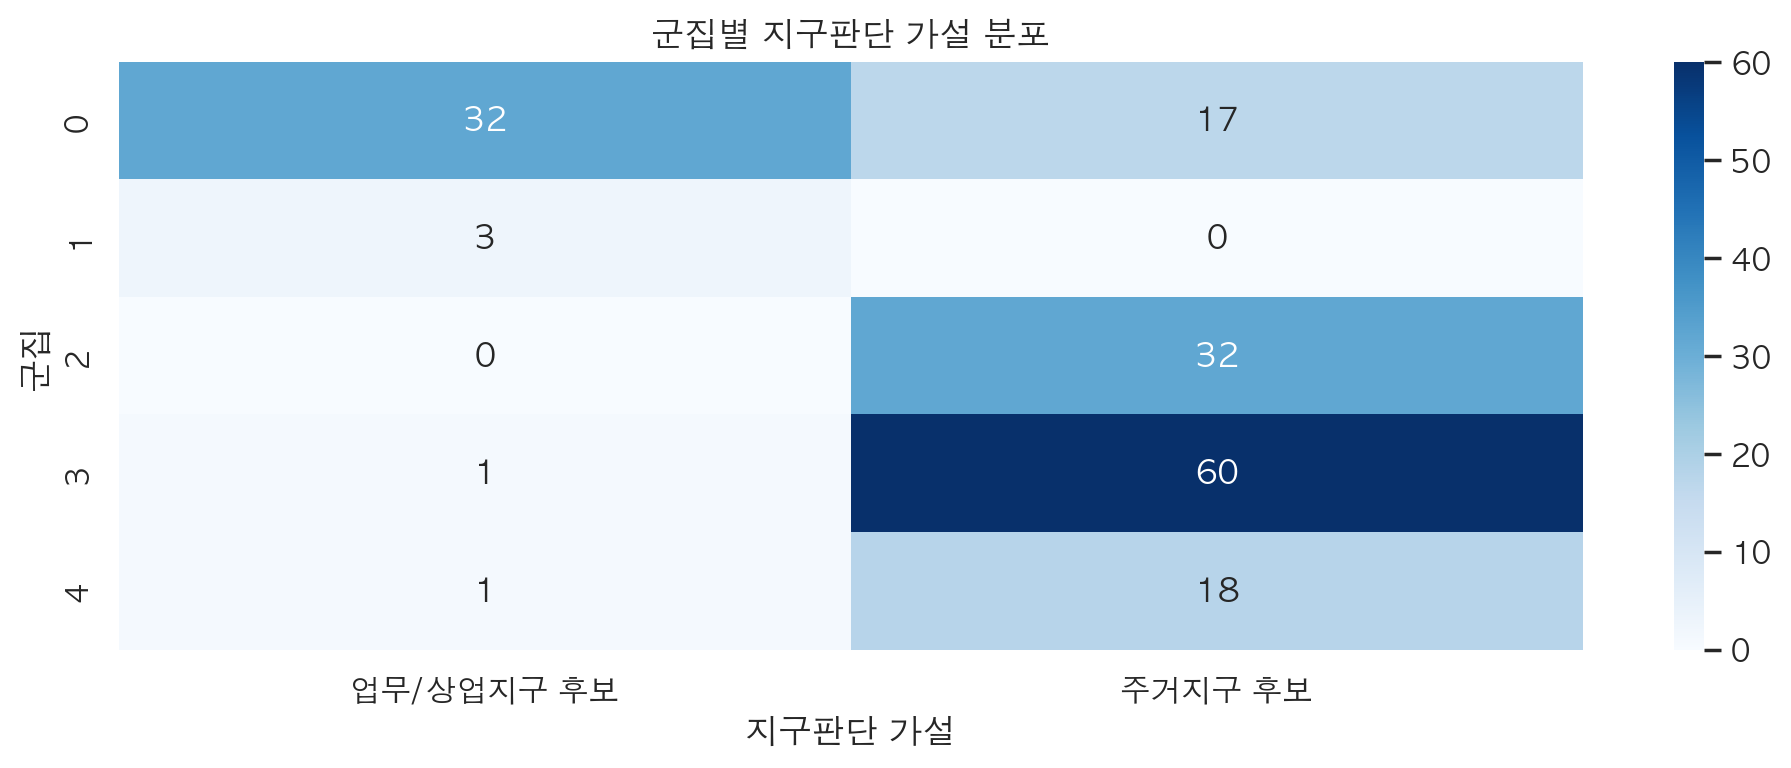

In [6]:
display(Markdown('### 추가 근거 차트'))
display(Image(filename=str(base_img_dir / 'ddri_second_cluster_size.png')))
display(Image(filename=str(base_img_dir / 'ddri_second_cluster_hypothesis_crosstab.png')))

In [7]:
key_cols = ['cluster', 'station_id', 'station_name', 'district_hypothesis', 'arrival_7_10_ratio', 'arrival_11_14_ratio', 'arrival_17_20_ratio', 'morning_net_inflow', 'evening_net_inflow']
display(Markdown('### 군집별 대표 대여소 3개'))
display(base_rep[key_cols].groupby('cluster').head(3).sort_values(['cluster', 'station_id']))

### 군집별 대표 대여소 3개

,cluster,station_id,station_name,district_hypothesis,arrival_7_10_ratio,arrival_11_14_ratio,arrival_17_20_ratio,morning_net_inflow,evening_net_inflow
1,0,2328,르네상스 호텔 사거리 역삼지하보도 7번출구 앞,업무/상업지구 후보,0.298792,0.203386,0.217520,739.0,-443.0
2,0,4902,구역삼세무서 교차로,업무/상업지구 후보,0.289955,0.180103,0.220412,1085.0,-767.0
0,0,4908,SB타워 앞,업무/상업지구 후보,0.280353,0.191687,0.217554,1091.0,-732.0
6,1,2323,주식회사 오뚜기 정문 앞,업무/상업지구 후보,0.584467,0.164167,0.110835,5101.0,-3404.0
7,1,2348,포스코사거리(기업은행),업무/상업지구 후보,0.508121,0.158094,0.152654,16019.0,-7627.0
5,1,2377,수서역 5번출구,업무/상업지구 후보,0.366424,0.157532,0.220654,10143.0,-3075.0
8,2,2312,청담역 13번 출구 앞,주거지구 후보,0.107911,0.138812,0.359489,-2109.0,465.0
9,2,2354,청담역 2번출구,주거지구 후보,0.117366,0.153308,0.375954,-325.0,473.0
10,2,4917,일원에코파크 주차장,주거지구 후보,0.129026,0.127652,0.362494,-2565.0,1774.0
14,3,2320,도곡역 대치지구대 방향,주거지구 후보,0.136159,0.211359,0.294554,248.0,382.0


### 정적 군집 지도

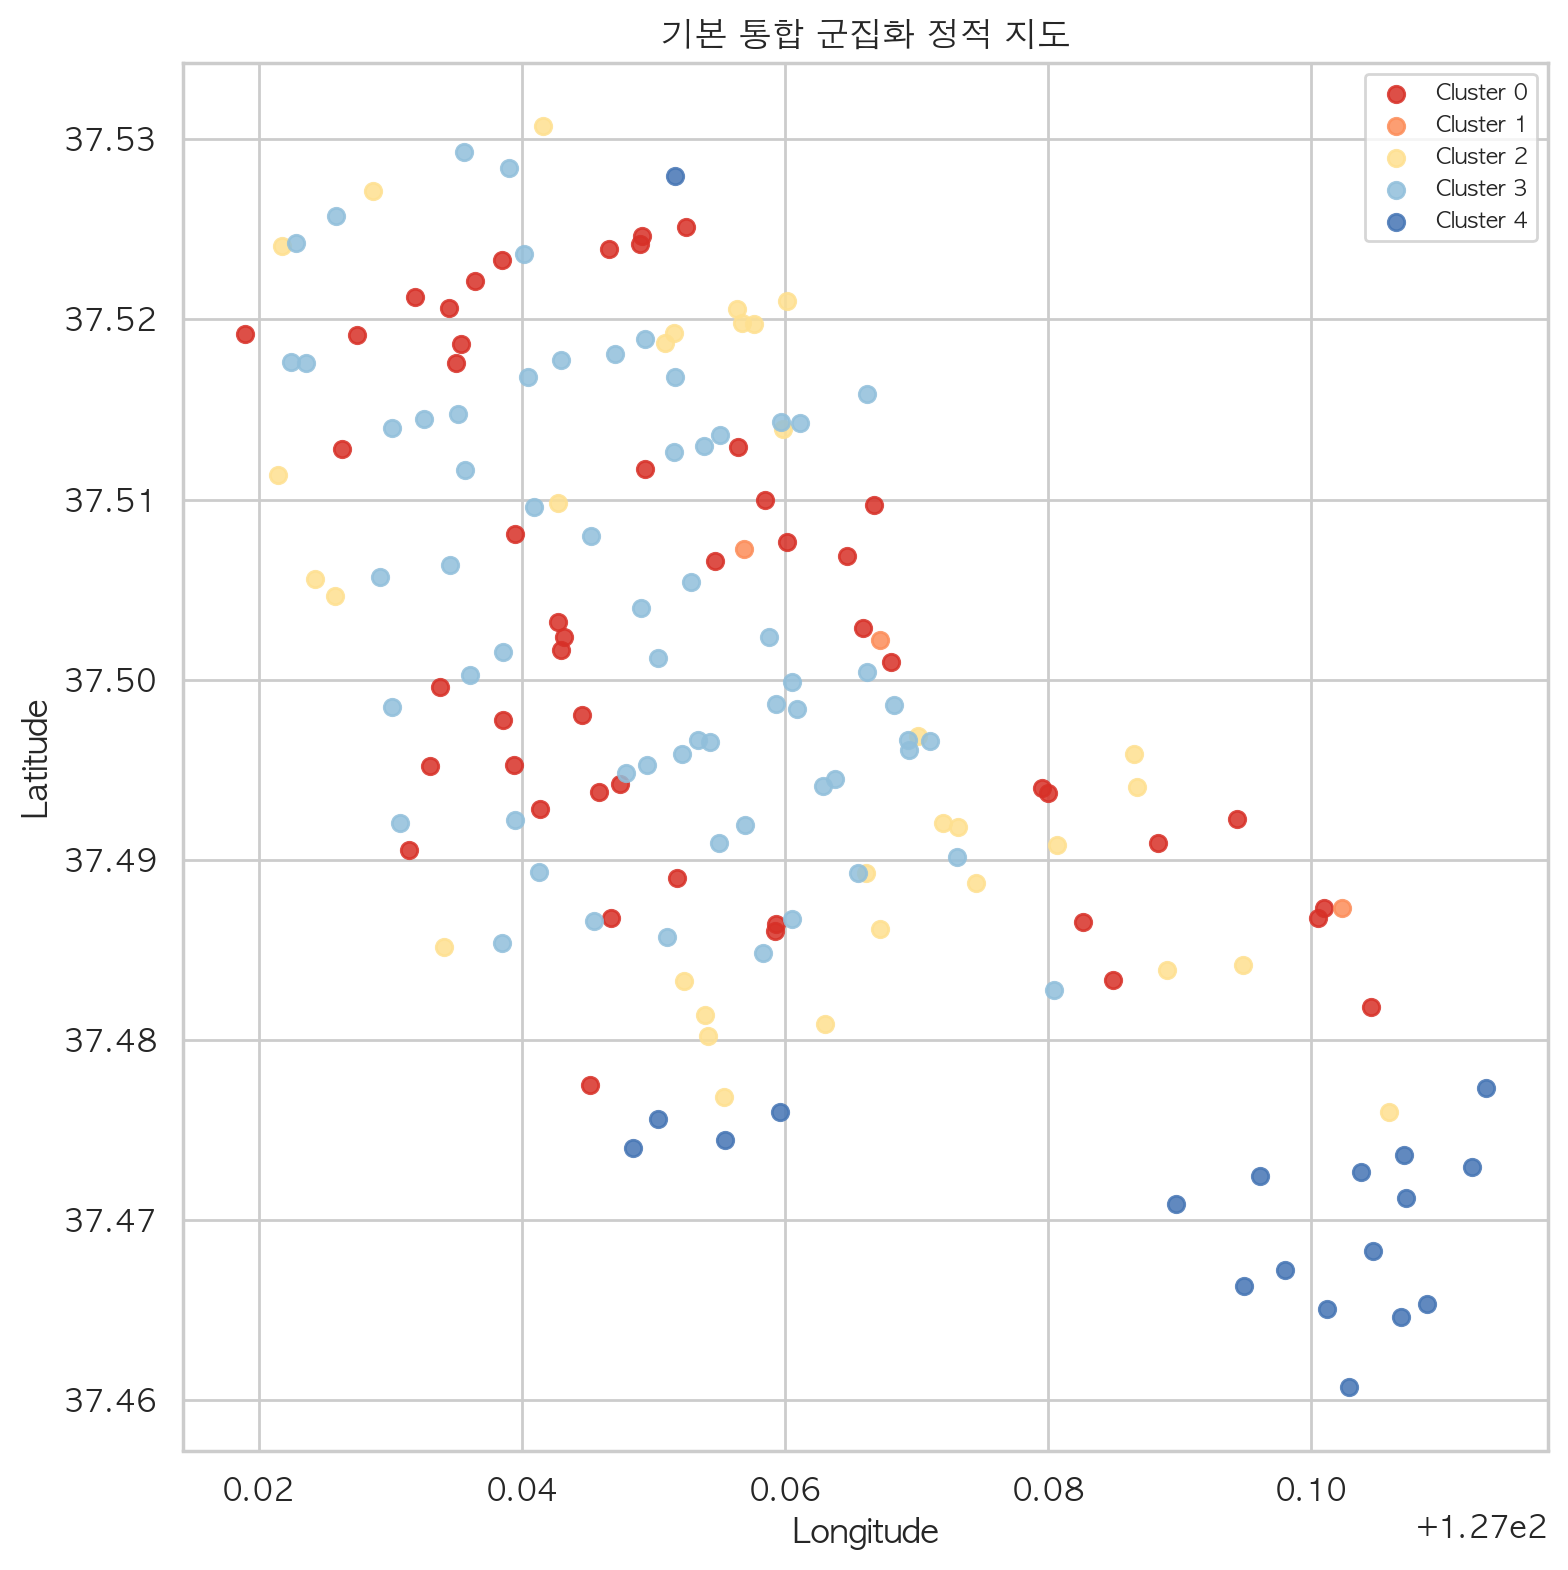

In [8]:
static_map_path = base_img_dir / 'ddri_second_cluster_static_map.png'

fig, ax = plt.subplots(figsize=(8, 8))
palette = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4', '#7b3294', '#1b9e77']
plot_df = base_train.dropna(subset=['latitude', 'longitude']).copy()
for cluster_id, group in plot_df.groupby('cluster'):
    color = palette[int(cluster_id) % len(palette)]
    ax.scatter(group['longitude'], group['latitude'], s=35, color=color, label=f'Cluster {cluster_id}', alpha=0.85)

ax.set_title('기본 통합 군집화 정적 지도')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='best', fontsize=8)
fig.tight_layout()
fig.savefig(static_map_path, dpi=200, bbox_inches='tight')
plt.close(fig)

display(Markdown('### 정적 군집 지도'))
display(Image(filename=str(static_map_path)))

### 핵심 피처의 군집별 분포

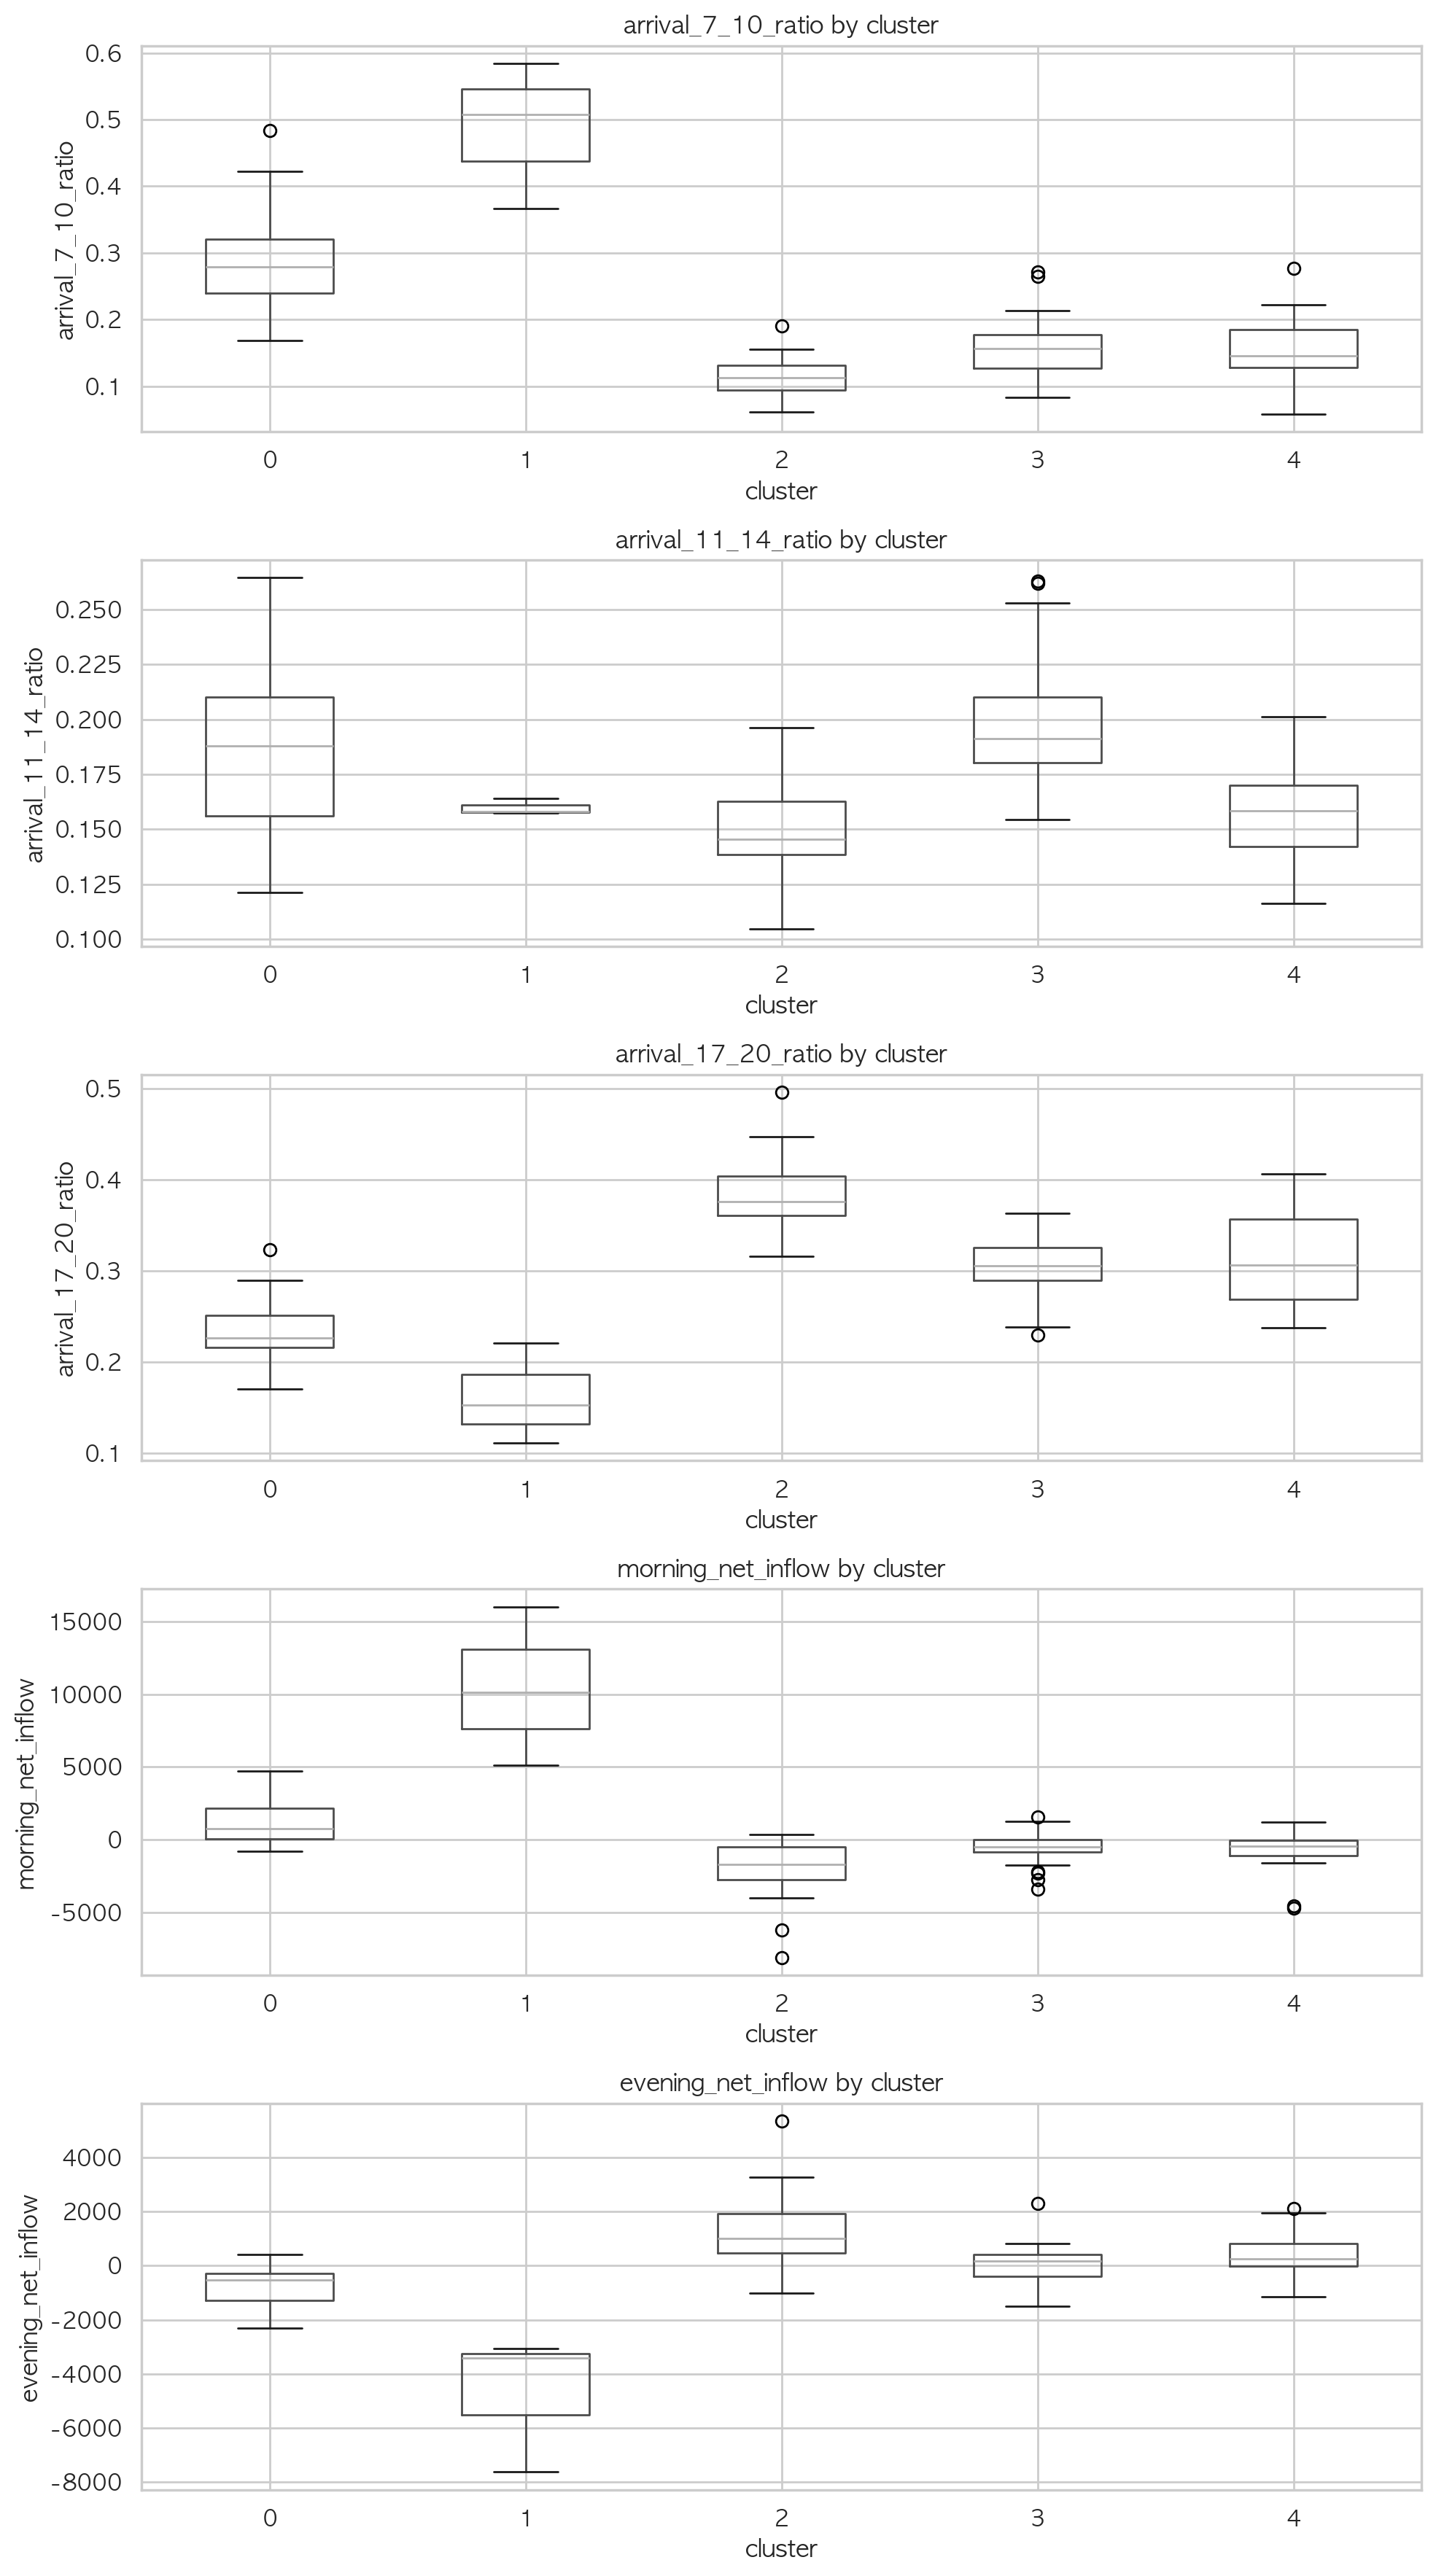

In [9]:
feature_cols = ['arrival_7_10_ratio', 'arrival_11_14_ratio', 'arrival_17_20_ratio', 'morning_net_inflow', 'evening_net_inflow']
fig, axes = plt.subplots(len(feature_cols), 1, figsize=(10, 18))
for ax, col in zip(axes, feature_cols):
    base_train.boxplot(column=col, by='cluster', ax=ax)
    ax.set_title(f'{col} by cluster')
    ax.set_xlabel('cluster')
    ax.set_ylabel(col)
plt.suptitle('')
fig.tight_layout()
boxplot_path = base_img_dir / 'ddri_second_cluster_key_feature_boxplots.png'
fig.savefig(boxplot_path, dpi=200, bbox_inches='tight')
plt.close(fig)
display(Markdown('### 핵심 피처의 군집별 분포'))
display(Image(filename=str(boxplot_path)))

## 3-2. 발표용 근거 해석 포인트

- `k` 탐색 차트: 왜 `k=5`를 채택했는지 설명
- 군집 규모 차트: 특정 군집이 극단적으로 작거나 과대하지 않은지 확인
- 가설 분포 히트맵: 군집이 실제로 업무/주거/상권 성격과 연결되는지 확인
- 정적 지도: 군집의 공간 분포를 한 장으로 보여주기
- 대표 대여소 표: 군집명을 실제 지점과 연결해 설명하기
- 핵심 피처 boxplot: 평균만이 아니라 분포 차이까지 제시

## 4. 반납 시간대 지도 근거

발표에서 직접 열어볼 수 있는 HTML 지도 파일 경로를 정리합니다.

추천 지도 3장:
- 2025년 07~10시 반납
- 2025년 11~14시 반납
- 2025년 17~20시 반납

In [10]:
return_map_dir = CHENG80 / 'return_time_district'
recommended_maps = [
    return_map_dir / 'ddri_return_map_2025_7_10.html',
    return_map_dir / 'ddri_return_map_2025_11_14.html',
    return_map_dir / 'ddri_return_map_2025_17_20.html',
]

for path in recommended_maps:
    print(path)

/Users/works/01_clustering/08_integrated/Desktop/ddri_work/works/01_clustering/08_integrated/return_time_district/ddri_return_map_2025_7_10.html
/Users/works/01_clustering/08_integrated/Desktop/ddri_work/works/01_clustering/08_integrated/return_time_district/ddri_return_map_2025_11_14.html
/Users/works/01_clustering/08_integrated/Desktop/ddri_work/works/01_clustering/08_integrated/return_time_district/ddri_return_map_2025_17_20.html


## 5. 환경 보강 피처 결과 요약

표고, 공원 규모, 도시자연공원구역 거리, 하천경계 거리의 기초 분포와 군집별 요약을 확인합니다.

공식 원천:
- 도시자연공원구역: https://data.seoul.go.kr/dataList/OA-21135/S/1/datasetView.do
- 하천경계 데이터: https://www.vworld.kr/dtmk/dtmk_ntads_s002.do?svcCde=MK&dsId=30248

In [11]:
env_dir = CHENG80 / 'environment_enrichment'
env_features = pd.read_csv(env_dir / 'ddri_environment_enrichment_features.csv')
env_summary = pd.read_csv(env_dir / 'ddri_environment_enrichment_cluster_summary.csv')
env_corr = pd.read_csv(env_dir / 'ddri_environment_enrichment_correlation.csv', index_col=0)

display(Markdown('### 환경 보강 피처 샘플'))
display(env_features.head())

display(Markdown('### 군집별 환경 보강 요약'))
display(env_summary)

display(Markdown('### 환경 보강 상관행렬'))
display(env_corr)

### 환경 보강 피처 샘플

,station_id,대여소명,주소,station_lat,station_lon,station_elevation_m,nearest_subway_name,nearest_subway_distance_m,subway_elevation_m,elevation_diff_nearest_subway_m,nearest_bus_stop_name,nearest_bus_stop_distance_m,bus_elevation_m,elevation_diff_nearest_bus_stop_m,nearest_park_name,nearest_park_distance_m,nearest_park_area_sqm,park_elevation_m,elevation_diff_nearest_park_m,distance_naturepark_m,inside_naturepark,distance_river_boundary_m
0,2301,현대고등학교 건너편,서울특별시 강남구 압구정로 134,37.524071,127.021790,15.0,압구정,676.393220,29.0,-14.0,신사중학교,31.690510,16.0,-1.0,도산근린공원,1169.547299,29816.5,30.0,-15.0,1943.599,0,510.630
1,2302,교보타워 버스정류장(신논현역 3번출구 후면),서울특별시 강남구 봉은사로 지하 102,37.505581,127.024277,20.0,신논현,129.301580,27.0,-7.0,교보타워,24.712821,23.0,-3.0,도산근린공원,2325.377527,29816.5,30.0,-10.0,1607.119,0,1991.707
2,2303,논현역 10번출구,서울특별시 강남구 학동로 지하 102,37.511372,127.021461,32.0,논현,31.250222,32.0,0.0,영동시장.논현역1번출구,87.593187,31.0,1.0,도산근린공원,1902.700297,29816.5,30.0,2.0,1768.310,0,1445.254
3,2304,대현그린타워,서울특별시 강남구 언주로 626,37.511627,127.035652,65.0,학동,455.995586,41.0,24.0,논현아이파크,58.750822,70.0,-5.0,도산근린공원,1451.909983,29816.5,30.0,35.0,2319.819,0,2262.668
4,2305,MCM 본사 직영점 앞,서울특별시 강남구 언주로 734,37.520641,127.034508,21.0,강남구청,683.890247,59.0,-38.0,제일은행.호림아트센터앞,110.921964,26.0,-5.0,도산근린공원,450.900687,29816.5,30.0,-9.0,2960.419,0,1348.501


### 군집별 환경 보강 요약

,cluster,station_elevation_m,elevation_diff_nearest_subway_m,elevation_diff_nearest_bus_stop_m,nearest_park_distance_m,nearest_park_area_sqm,elevation_diff_nearest_park_m,distance_naturepark_m,inside_naturepark,distance_river_boundary_m
0,0,31.94,-0.41,0.16,888.24,332814.50,-32.57,1538.55,0.00,1001.06
1,1,22.67,3.00,-2.00,1103.25,391939.33,-31.00,1349.91,0.00,572.88
2,2,28.38,-4.25,-0.31,1119.91,668321.80,-39.50,1408.52,0.00,629.38
3,3,32.34,2.30,-0.07,1106.09,414114.58,-32.18,1571.69,0.00,1060.25
4,4,31.89,3.84,1.32,1286.24,613957.05,-15.53,475.40,0.05,374.79


### 환경 보강 상관행렬

,station_elevation_m,elevation_diff_nearest_subway_m,elevation_diff_nearest_bus_stop_m,nearest_park_distance_m,nearest_park_area_sqm,elevation_diff_nearest_park_m,distance_naturepark_m,inside_naturepark,distance_river_boundary_m,arrival_7_10_ratio,arrival_11_14_ratio,arrival_17_20_ratio,morning_net_inflow,evening_net_inflow
station_elevation_m,1.000,0.496,0.213,-0.030,-0.006,0.387,0.113,0.087,0.572,-0.073,0.091,-0.064,-0.232,-0.223
elevation_diff_nearest_subway_m,0.496,1.000,0.202,0.137,0.033,0.155,-0.245,0.027,0.207,-0.015,0.257,-0.081,-0.001,-0.151
elevation_diff_nearest_bus_stop_m,0.213,0.202,1.000,-0.070,0.023,0.002,-0.003,0.107,-0.040,-0.008,0.011,-0.034,-0.070,0.020
nearest_park_distance_m,-0.030,0.137,-0.070,1.000,0.315,-0.175,-0.266,0.128,0.083,-0.114,-0.026,0.100,-0.083,0.153
nearest_park_area_sqm,-0.006,0.033,0.023,0.315,1.000,-0.416,-0.386,0.212,-0.299,-0.154,-0.104,0.132,-0.178,0.105
elevation_diff_nearest_park_m,0.387,0.155,0.002,-0.175,-0.416,1.000,0.456,-0.040,0.280,-0.038,0.076,-0.054,-0.062,-0.032
distance_naturepark_m,0.113,-0.245,-0.003,-0.266,-0.386,0.456,1.000,-0.104,0.231,0.001,0.126,-0.079,0.036,-0.094
inside_naturepark,0.087,0.027,0.107,0.128,0.212,-0.040,-0.104,1.000,-0.058,-0.014,0.046,-0.047,0.003,-0.002
distance_river_boundary_m,0.572,0.207,-0.040,0.083,-0.299,0.280,0.231,-0.058,1.000,0.058,0.329,-0.191,0.006,-0.199
arrival_7_10_ratio,-0.073,-0.015,-0.008,-0.114,-0.154,-0.038,0.001,-0.014,0.058,1.000,0.133,-0.805,0.711,-0.647


## 6. 환경 보강 군집화 결과 비교

환경 보강 피처를 포함했을 때 실루엣 점수와 해석력이 어떻게 달라지는지 확인합니다.

In [12]:
enriched_result_dir = CHENG80 / 'enriched_second_clustering_results'
enriched_data_dir = enriched_result_dir / 'data'
enriched_img_dir = enriched_result_dir / 'images'

enriched_k = pd.read_csv(enriched_data_dir / 'ddri_enriched_kmeans_search_metrics.csv')
enriched_summary = pd.read_csv(enriched_data_dir / 'ddri_enriched_cluster_summary.csv')

compare_df = base_k.rename(columns={'silhouette': 'base_silhouette', 'inertia': 'base_inertia'}).merge(
    enriched_k.rename(columns={'silhouette': 'enriched_silhouette', 'inertia': 'enriched_inertia'}),
    on='k',
    how='inner'
)

display(Markdown('### 기본 vs 환경 보강 비교'))
display(compare_df)

display(Markdown('### 환경 보강 군집 요약'))
display(enriched_summary)

### 기본 vs 환경 보강 비교

,k,base_inertia,base_silhouette,enriched_inertia,enriched_silhouette
0,5,542.473316,0.203280,1186.336073,0.156915
1,6,498.332146,0.179541,1092.821741,0.157690
2,7,465.907711,0.170796,1024.625305,0.145608


### 환경 보강 군집 요약

,cluster,arrival_7_10_ratio,arrival_11_14_ratio,arrival_17_20_ratio,morning_net_inflow,evening_net_inflow,subway_distance_m,bus_stop_count_300m,station_elevation_m,elevation_diff_nearest_subway_m,nearest_park_area_sqm,distance_naturepark_m,distance_river_boundary_m,station_count
0,0,0.2074,0.2041,0.2644,-182.5833,-493.8333,400.2423,26.3333,44.0833,9.6111,2.071503e+05,1721.0716,1646.1942,36
1,1,0.1537,0.1530,0.3261,-1192.8000,813.1000,1577.3415,27.6000,31.4500,4.0000,5.130275e+05,303.5253,387.5622,20
2,2,0.1356,0.1755,0.3252,-1532.7500,478.8750,256.9479,28.3750,29.1250,0.5000,2.277252e+06,637.5796,368.2122,16
3,3,0.1335,0.1789,0.3462,-889.0196,581.6078,316.1771,30.9804,26.6078,-2.0000,2.257377e+05,1482.2510,797.6130,51
4,4,0.2491,0.1755,0.2544,571.0000,-338.7500,473.4566,20.2857,27.9286,-9.6786,1.857145e+05,2294.8709,742.6590,28
5,5,0.3693,0.1743,0.2119,4781.6923,-2311.3846,419.0896,39.3846,23.0000,0.3846,3.791980e+05,871.9585,640.6867,13


### 환경 보강 차트

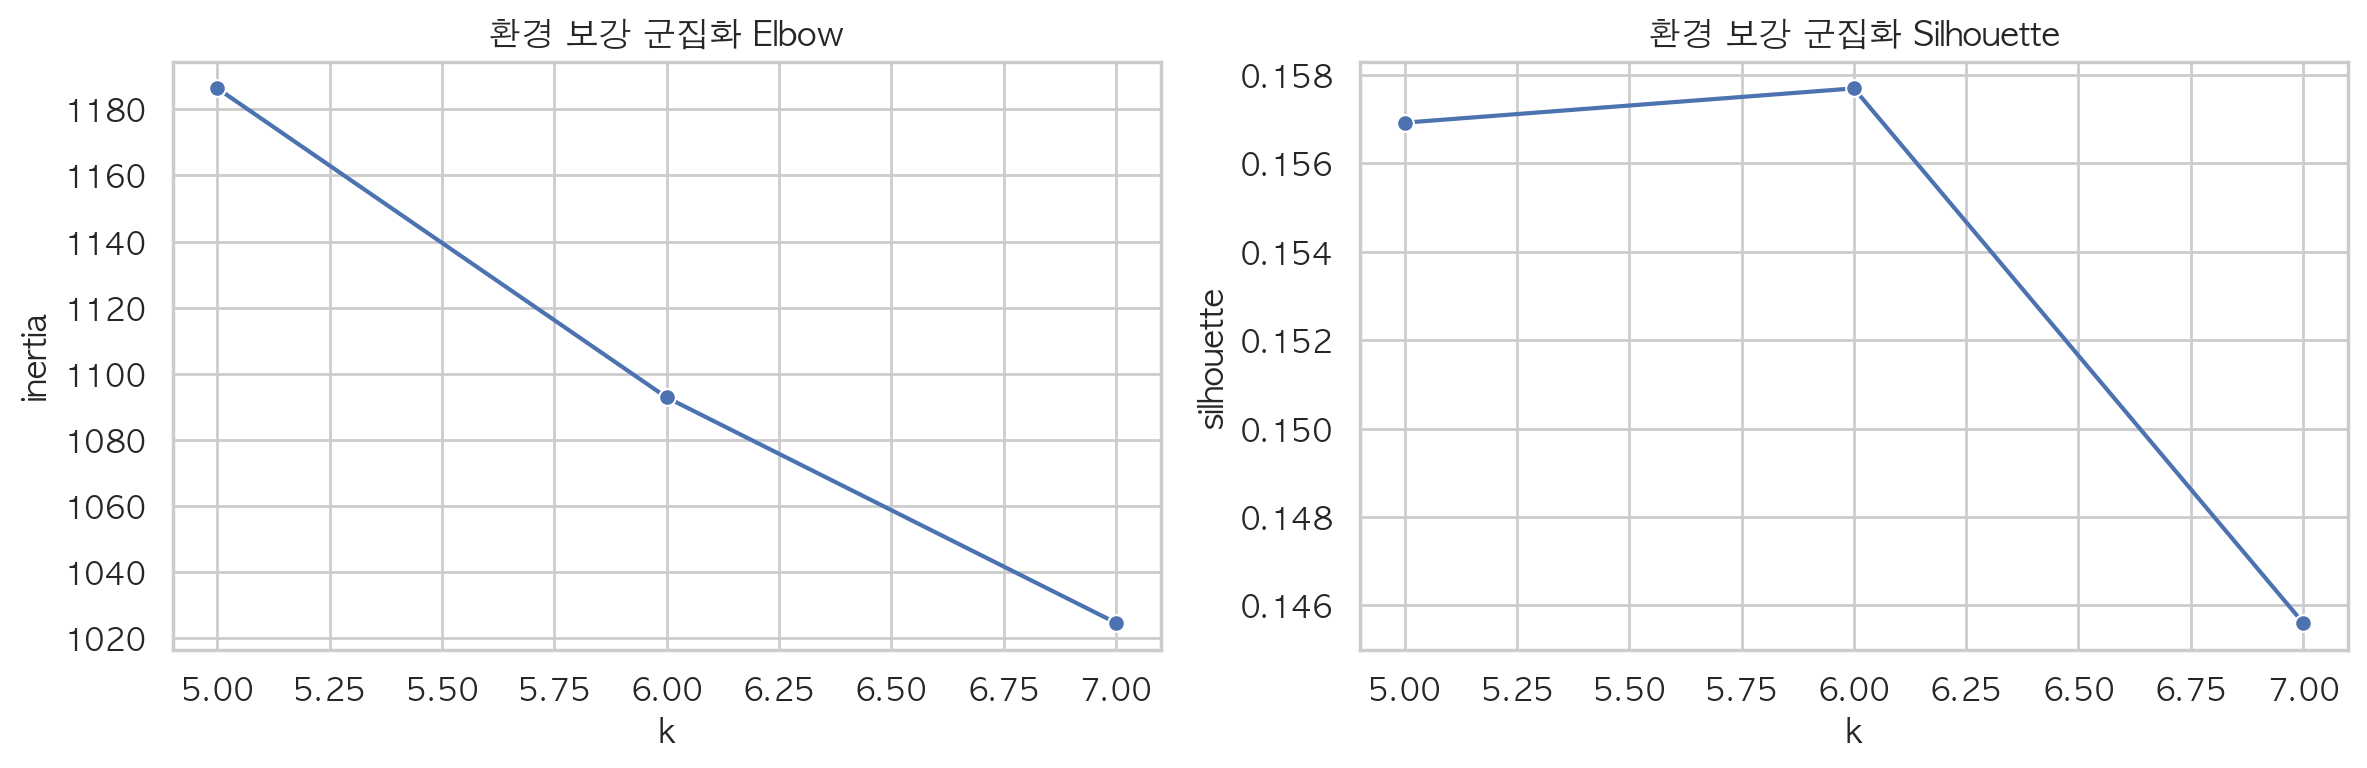

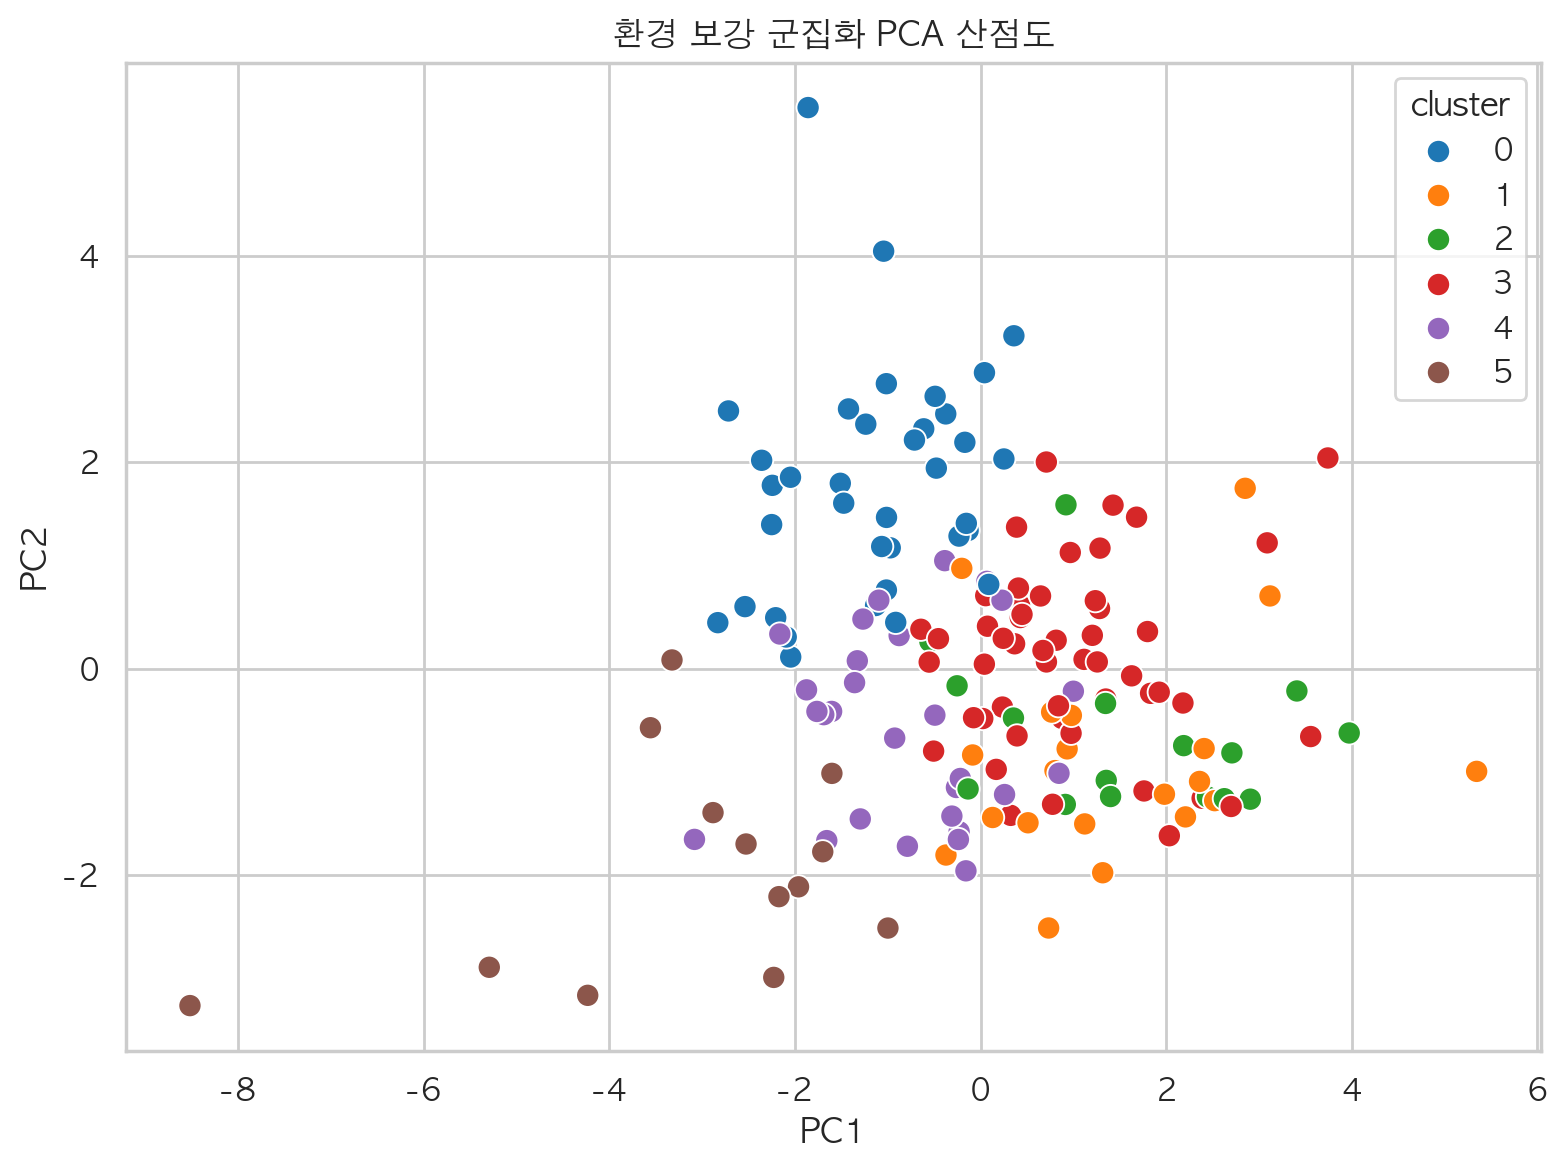

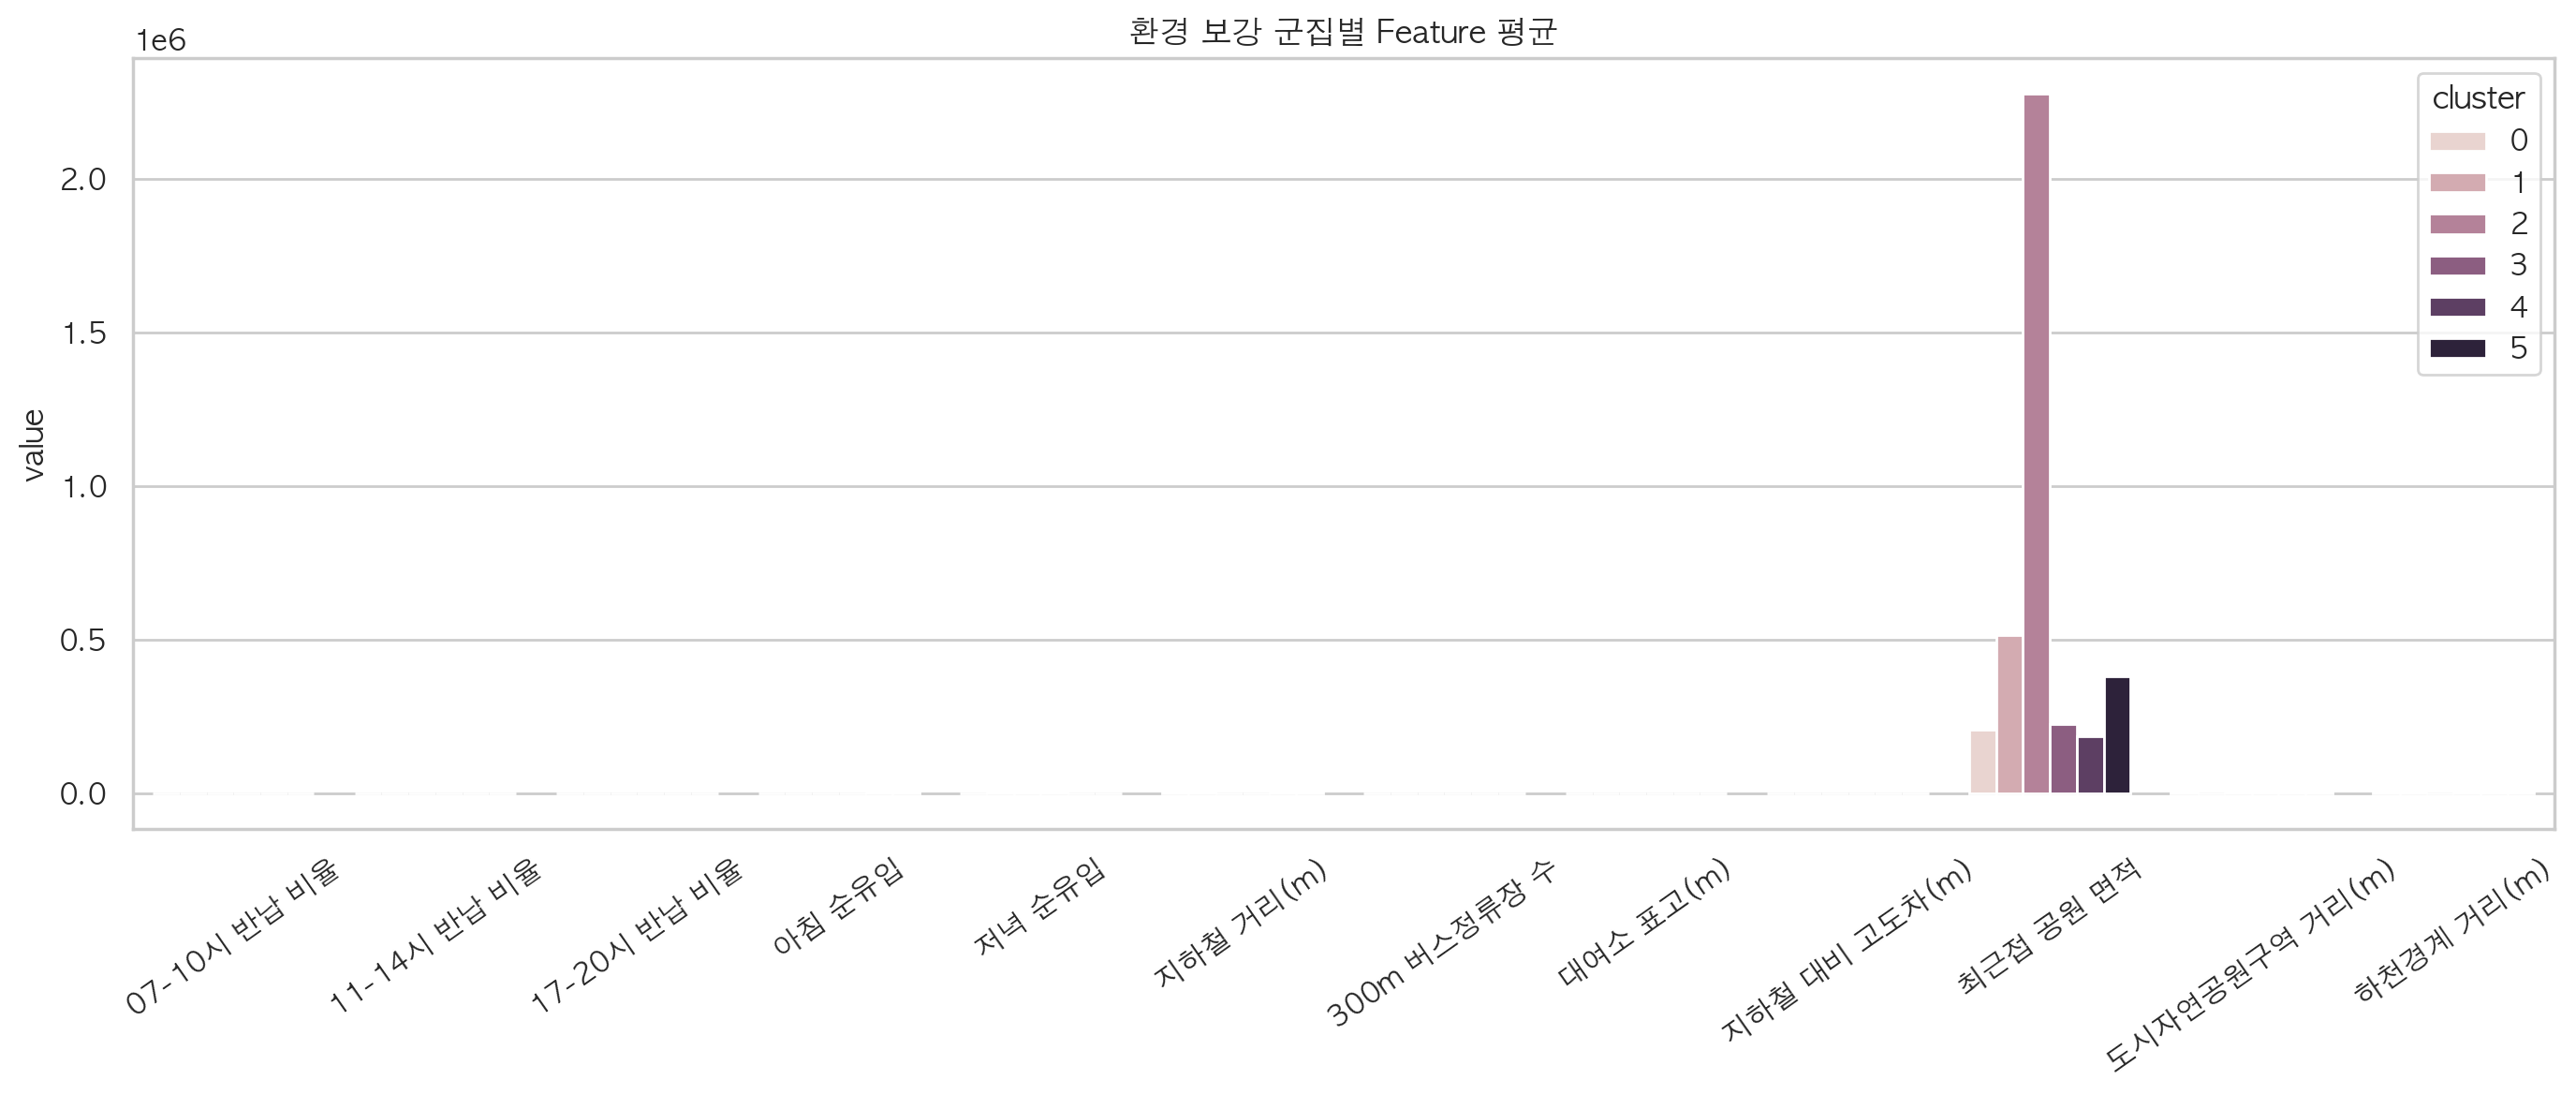

In [13]:
display(Markdown('### 환경 보강 차트'))
display(Image(filename=str(enriched_img_dir / 'ddri_enriched_kmeans_elbow_silhouette.png')))
display(Image(filename=str(enriched_img_dir / 'ddri_enriched_kmeans_pca_scatter.png')))
display(Image(filename=str(enriched_img_dir / 'ddri_enriched_cluster_feature_means.png')))

## 7. 발표용 결론 정리

현재 기준 발표 메시지:
- 메인 결과는 `기본 통합 군집화(k=5)`를 사용
- 반납 시간대, 순유입, 교통 접근성을 통해 `업무/상업형`, `주거형`, `생활·상권 혼합형`, `외곽 주거형` 해석이 가능
- 환경 보강 피처는 `외곽성`, `녹지성`, `수변 접근성` 해석을 강화하지만, 현재는 메인 군집 분리도 개선까지는 이어지지 않음
- 최종 목적은 이후 `station-day` 수요 예측에서 군집별로 날씨·생활인구·고저차 피처를 더 정교하게 선택하는 것

In [14]:
display(Markdown('### 발표용 한 줄 정리'))

best_base = int(base_k.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]['k'])
best_base_score = float(base_k.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]['silhouette'])
best_enriched = int(enriched_k.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]['k'])
best_enriched_score = float(enriched_k.sort_values(['silhouette', 'k'], ascending=[False, True]).iloc[0]['silhouette'])

print(f'기본 통합 군집화 최적: k={best_base}, silhouette={best_base_score:.4f}')
print(f'환경 보강 군집화 최적: k={best_enriched}, silhouette={best_enriched_score:.4f}')
print('발표 메인 결과는 기본 통합 군집화, 환경 보강은 해석 보조 결과로 제시')

### 발표용 한 줄 정리

기본 통합 군집화 최적: k=5, silhouette=0.2033
환경 보강 군집화 최적: k=6, silhouette=0.1577
발표 메인 결과는 기본 통합 군집화, 환경 보강은 해석 보조 결과로 제시
